In [1]:
""" Compare against Colleen's resin exchange data

Seasonal cycle is opposite between net mineralization and resin exchange
There is not great contrast between old and modified model. 
So, just show one annual graph to illustrate this. 
"""
import pandas as pd
import numpy as np
import os
from datetime import datetime
from utils.constants import chamber_levels_complete, chamber_list_complete_dict
import matplotlib.pyplot as plt
from glob import glob
import xarray as xr
from scipy.stats import spearmanr
import itertools as it
from utils.analysis import vert_interp
from scipy.stats import linregress
from matplotlib import rcParams

rcParams['axes.titlesize'] = 14
rcParams['font.size'] = 14


LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                    0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                    7.829766, 12.92532, 21.32647, 35.17762])
LEVGRND_I = np.append(np.insert(
    (LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
THICKNESS = np.diff(LEVGRND_I)


chambers_ordered = {
    'amb': ['06', '20', '13', '08', '17'],  # '07', 
    'elev': ['19', '11', '04', '16', '10']
}
depth_list = ['0.1', '0.3', '0.6']

mossfrac = pd.read_excel(
    os.path.join(os.environ['HOME'], 'Git', 'phenology_elm', "Sphagnum_fraction.xlsx"),
    index_col=0, skiprows=1, engine="openpyxl"
).drop(["plot", "Temp", "CO2"], axis=1)
mossfrac[2015] = mossfrac[2016]
mossfrac.sort_index(axis = 1, inplace = True)

In [2]:
################################################################
# Collect the observed monthly nutrients exchange
################################################################
data = pd.read_csv(
    os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                 'SPRUCE_Available_Nutrients_Ion-Exchange-Resins_Monthly_2014-2021.csv'),
    na_values = -9999
)
data = data.loc[data['Year'] >= 2015, :]
data['Peat_depth'] = data['Peat_depth'].map({10: 0.1, 30: 0.3, 60: 0.6})
data['Plot'] = [f'{p:02d}' for p in data['Plot']]

data['Deployed'] = ' '*20
data['Collected'] = ' '*20

# attach the deployment dates
deploy_dates = pd.read_csv(
    os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                 'collection_dates_from_Soren.csv'),
)

for i, row in data.iterrows():
    if row['Subplot'] == 'A':
        data.loc[i, 'Deployed'] = deploy_dates.loc[row['Collection_no'], 'deployed_a']
        data.loc[i, 'Collected'] = deploy_dates.loc[row['Collection_no'], 'collected_a']
    else:
        data.loc[i, 'Deployed'] = deploy_dates.loc[row['Collection_no'], 'deployed_b']
        data.loc[i, 'Collected'] = deploy_dates.loc[row['Collection_no'], 'collected_b']
data['Deployed'] = pd.DatetimeIndex([datetime.strptime(d, '%d-%b-%y') for d in data['Deployed']])
data['Collected'] = pd.DatetimeIndex([datetime.strptime(d, '%d-%b-%y') for d in data['Collected']])


# Subset to only 2016 & 2017
# 
# the last quarter of 2015 & 2018 has little data
# years after 2019 do not have monthly information
# data_collect.loc[data_collect.index.year == 2019, :].dropna(axis = 1, how = 'all').plot()
is_nan = []

data_collect = {}
for d, col in it.product([0.1, 0.3, 0.6], ['hummock', 'hollow']):
    for i, plot in enumerate(chambers_ordered['amb'] + chambers_ordered['elev']):
        subset = data.loc[(data['Plot'] == plot) & (data['Microtopography'] == col.capitalize()) & \
                          (data['Peat_depth'] == d), :]

        temp = subset.loc[subset['Subplot'] == 'A', :]
        if len(temp) == 0:
            continue
        temp_temp = pd.Series(np.nan, index = pd.date_range(temp['Deployed'].min(),
                                                            temp['Collected'].max(), freq = '1D'))
        for j, row in temp.iterrows():
            temp_temp.loc[row['Deployed']:row['Collected']] = row['Ammonium']
        if sum(temp_temp.isna()) > 0:
            is_nan.append([plot, d, 'A', sum(temp_temp.isna())])
        temp_temp = temp_temp.interpolate(method = 'linear')
        temp_temp = temp_temp.loc[(temp_temp.index.year >= 2016) & (temp_temp.index.year <= 2017)]
        data_collect[(d, col, plot, 'A')] = temp_temp

        temp2 = subset.loc[subset['Subplot'] == 'B', :]
        if len(temp2) == 0:
            continue
        temp_temp2 = pd.Series(np.nan, index = pd.date_range(temp2['Deployed'].min(),
                                                             temp2['Collected'].max(), freq = '1D'))
        for j, row in temp2.iterrows():
            temp_temp2.loc[row['Deployed']:row['Collected']] = row['Ammonium']
        if sum(temp_temp2.isna()) > 0:
            is_nan.append([plot, d, 'B', sum(temp_temp2.isna())])
        temp_temp2 = temp_temp2.interpolate(method = 'linear')
        temp_temp2 = temp_temp2.loc[(temp_temp2.index.year >= 2016) & \
                                    (temp_temp2.index.year <= 2017)]
        data_collect[(d, col, plot, 'B')] = temp_temp2

data_collect = pd.DataFrame(data_collect)

In [3]:
################################################################
# Collect modeled uptake of nutrients, layerwise
################################################################
ensemble_id = None
year_range = range(2015, 2022)
plot_list = list(chamber_levels_complete.keys())

prefix_list = ['20231116', '20240326']

sims_data = {}
for prefix in prefix_list:
    sims_data[prefix] = {}
    for varname, col, depth in it.product(
        ['SMINN_TO_PLANT', 'SMINP_TO_PLANT', 'NET_NMIN', 'NET_PMIN', 'ACTUAL_IMMOB', 
         'ACTUAL_IMMOB_P', 'TSOI'], ['hummock', 'hollow'], [0.1, 0.3, 0.6]
    ):
        sims_data[prefix][(varname, col, depth)] = pd.DataFrame(np.nan, columns = plot_list,
                            index = pd.date_range('2015-01-01', '2021-12-31', freq = '1D'))
        sims_data[prefix][(varname, col, depth)] = \
            sims_data[prefix][(varname, col, depth)].loc[ \
                ~((sims_data[prefix][(varname, col, depth)].index.month == 2) & \
                  (sims_data[prefix][(varname, col, depth)].index.day == 29)), :]


    for varname, col, plot in it.product(
        ['SMINN_TO_PLANT', 'SMINP_TO_PLANT', 'NET_NMIN', 'NET_PMIN', 'ACTUAL_IMMOB', 
         'ACTUAL_IMMOB_P', 'TSOI'], ['hummock', 'hollow'], plot_list
    ):
        if not "UQ" in prefix:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run')
        else:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ensemble_id, 
                                f'P{chamber_list_complete_dict[plot]}')

        if col == 'hummock':
            hol_add = 0
        else:
            hol_add = 1

        flist = sorted(glob(rundir + "/*.h1.*.nc"))
        flist = [f for f in flist if \
                int(f.split('/')[-1].split('.')[-2].split('-')[0]) in year_range]
        hr = xr.open_mfdataset(flist)

        if varname != 'TSOI':
            var_ = f'{varname}_vr'
        else:
            var_ = varname
        result = vert_interp([0.1, 0.3, 0.6], LEVGRND[:10], 
                             hr[var_][:, :10, hol_add].values, 
                             True, None, LEVGRND_I[:10]
                             )
        if varname != 'TSOI':
            result = result * 365 * 86400 # gN/P m-3 s-1 => year-1

        for j, depth in enumerate([0.1, 0.3, 0.6]):
            sims_data[prefix][(varname, col, depth)].loc[:, plot] = result[:, j]

        hr.close()

In [4]:
################################################################
# Convert the data to seasonal cycle only
################################################################

# convert each year's data into seasonal cycle by 
# dividing with the year's average
obs_seasonality = data_collect.copy(deep = True)
for year in range(2016, 2018):
    temp = obs_seasonality.loc[obs_seasonality.index.year == year, :]
    temp = temp / temp.mean(axis = 0)
    obs_seasonality.loc[obs_seasonality.index.year == year, :] = temp.values

sims_seasonality = {}
for prefix in prefix_list:
    sims_seasonality[prefix] = {}
    for varname, col, depth in it.product(
        ['SMINN_TO_PLANT', 'SMINP_TO_PLANT', 'NET_NMIN', 'NET_PMIN', 'ACTUAL_IMMOB', 
         'ACTUAL_IMMOB_P'], ['hummock', 'hollow'], [0.1, 0.3, 0.6]
    ):
        sims_seasonality[prefix][(varname, col, depth)] = \
            sims_data[prefix][(varname, col, depth)].copy()
        for year in range(2015, 2022):
            temp = sims_seasonality[prefix][(varname, col, depth)].loc[
                sims_seasonality[prefix][(varname, col, depth)].index.year == year, :
            ]
            temp = temp / temp.mean(axis = 0)
            sims_seasonality[prefix][(varname, col, depth)].loc[ \
                sims_seasonality[prefix][(varname, col, depth)].index.year == year, :] = temp.values

/tmp/ipykernel_1384502/3044277624.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = obs_seasonality.loc[:, (d, col)]


(1.0, 365.0, -1.0171378357115612, 10.831886215204428)

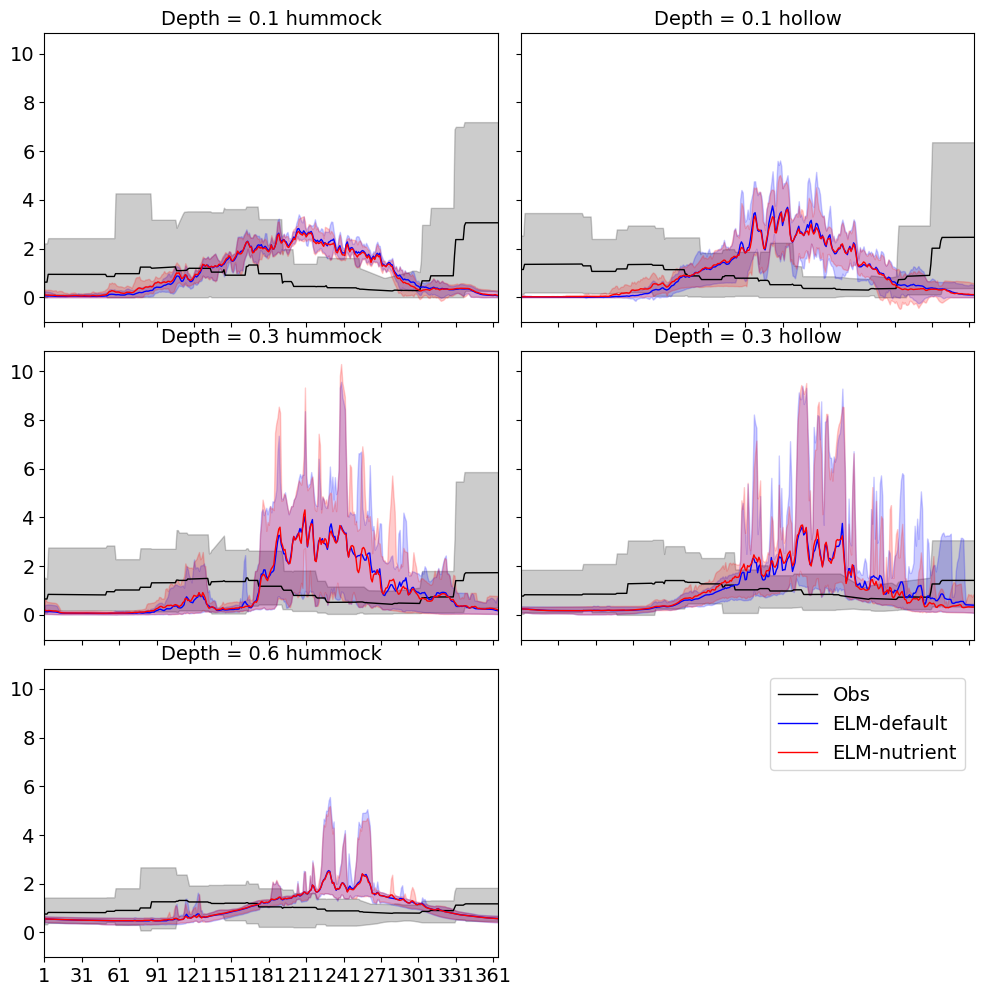

In [5]:
# Cycle relative to annual mean
varname = 'NET_NMIN'

fig, axes = plt.subplots(3, 2, figsize = (12, 12), sharex = True, sharey = True)
fig.subplots_adjust(hspace = 0.1, wspace = 0.05)
for k, d in enumerate([0.1, 0.3, 0.6]):
    for i, col in enumerate(['hummock', 'hollow']):
        ax = axes[k,i]

        if (d == 0.6) & (col == 'hollow'):
            continue

        # observed
        temp = obs_seasonality.loc[:, (d, col)]
        temp = temp.loc[~((temp.index.month == 2) & (temp.index.day == 29)), :]
        temp = temp.values.reshape(2, 365, temp.shape[1])
        temp = temp.transpose([1, 0, 2]).reshape(365, -1)

        temp_mean = np.mean(temp, axis = 1)
        temp_max = np.nanpercentile(temp, 95, axis = 1)
        temp_min = np.nanpercentile(temp, 5, axis = 1)

        h1, = ax.plot(range(1, 366), temp_mean, '-', linewidth=1, label = d, color = 'k')
        ax.fill_between(range(1, 366), temp_min, temp_max, alpha = 0.2, color = 'k')

        # simulated
        h2 = []
        for prefix, color in zip(prefix_list, ['b', 'r']):
            temp = sims_seasonality[prefix][(varname, col, d)]
            temp = temp.loc[(temp.index.year == 2016) | (temp.index.year == 2017), :]
            temp = temp.values.reshape(2, 365, temp.shape[1])
            temp = temp.transpose([1, 0, 2]).reshape(365, -1)

            temp_mean = np.mean(temp, axis = 1)
            temp_max = np.nanpercentile(temp, 95, axis = 1)
            temp_min = np.nanpercentile(temp, 5, axis = 1)

            htemp, = ax.plot(range(1, 366), temp_mean, '-', linewidth=1, label = d, color = color)
            ax.fill_between(range(1, 366), temp_min, temp_max, alpha = 0.2, color = color)
            h2.append(htemp)

        ax.set_title(f'Depth = {d} {col}')
        ax.set_xticks(range(1, 366, 30))
        ax.set_xlim([1, 365])
ax.legend([h1] + h2, ['Obs','ELM-default', 'ELM-nutrient'])
axes[-1,-1].axis('off')

In [6]:
################################################################
# Read the annual data
################################################################
data = pd.read_csv(
    os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                 'SPRUCE_Available_Nutrients_Ion-Exchange-Resins_Annual_2014-2018.csv'),
    na_values = -9999
)
data = data.loc[data['Year'] >= 2015, :]
data['Peat_depth'] = data['Peat_depth'].map({10: 0.1, 30: 0.3, 60: 0.6})
data['Plot'] = [f'{p:02d}' for p in data['Plot']]

# convert the simulated daily data to annual data
sims_data_annual = {}
for prefix in prefix_list:
    sims_data_annual[prefix] = {}
    for key in sims_data[prefix].keys():
        sims_data_annual[prefix][key] = sims_data[prefix][key].resample('1Y').mean()
        sims_data_annual[prefix][key].index = sims_data_annual[prefix][key].index.year

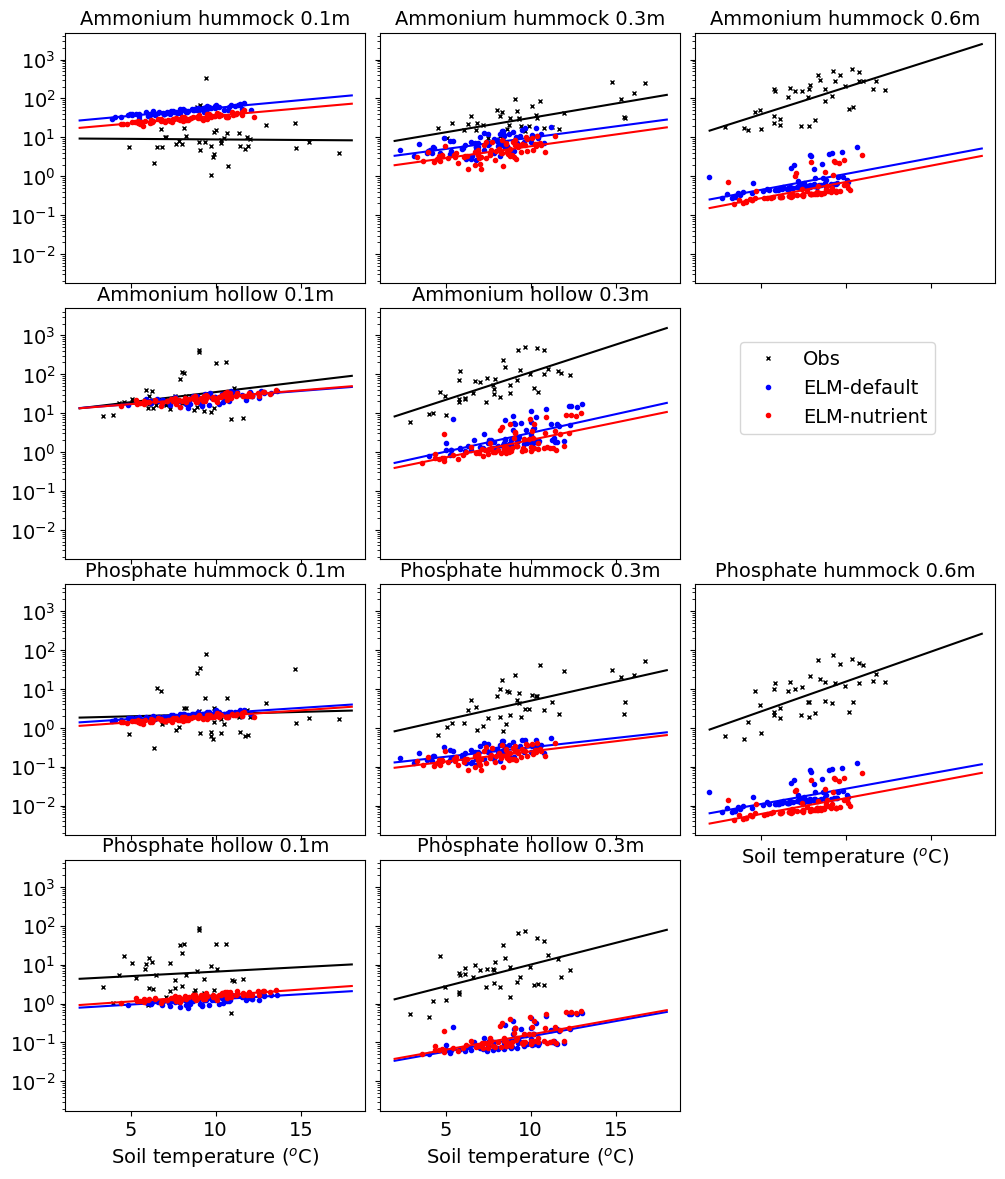

In [7]:
#xticklabels = ['T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00',  # 'TAMB', 
#               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']
#clist = ['#1b9e77', '#d95f02', '#7570b3']


# Plot the sensitivity to peat temperature
fig, axes = plt.subplots(4, 3, figsize = (12, 14), sharex = True, sharey = True)
fig.subplots_adjust(hspace = 0.1, wspace = 0.05)
for n, nu, sim_name, obs_name in zip(
    [0, 1], ['N', 'P'], ['NET_NMIN', 'NET_PMIN'], ['Ammonium', 'Phosphate']
):
    for i, hol in enumerate(['hummock', 'hollow']):
        for d, depth in enumerate([0.1, 0.3, 0.6]):
            ax = axes.flat[n * 6 + i * 3 + d]

            if (hol == 'hollow') and (depth == 0.6):
                ax.axis('off')
                continue

            # observed temperature & data
            obs_temp = data.loc[(data['Microtopography'] == hol.capitalize()) &
                                np.isclose(data['Peat_depth'], depth), 
                ['Plot', 'Year', 'Annual_Peat_temperature', 
                obs_name]].groupby(['Plot','Year']).mean()

            ax.plot(obs_temp['Annual_Peat_temperature'], obs_temp[obs_name], 'x', 
                    label = f'Obs', color = 'k', # clist[d], # markerfacecolor = 'none', 
                    markersize = 3)
            res = linregress(obs_temp['Annual_Peat_temperature'], np.log(obs_temp[obs_name]))
            ax.plot([2,18], np.exp(res.intercept + res.slope * np.array([2,18])), color = 'k') #  clist[d])

            # growing season simulated data
            for prefix, name, col in zip(prefix_list, ['ELM-default','ELM-nutrient'], 
                                         ['b', 'r']):
                sims_tsoi = sims_data_annual[prefix][('TSOI', hol, depth)].unstack()
                sims_tsoi.index.names = ['Plot', 'Year']
                sims_tsoi = sims_tsoi.to_frame('TSOIL')

                sims_data_var = sims_data_annual[prefix][(sim_name, hol, depth)].unstack()
                sims_data_var.index.names = ['Plot', 'Year']
                sims_data_var = sims_data_var.to_frame(sim_name)

                # put together
                alldata = pd.concat([sims_tsoi, sims_data_var], axis = 1
                                    ).dropna(axis = 0, how = 'any')

                ax.plot(alldata['TSOIL'] - 273.15, alldata[sim_name], 'o', 
                        label = name, color = col, # markerfacecolor = 'none', 
                        markersize = 3)
                res = linregress(alldata['TSOIL'] - 273.15, np.log(alldata[sim_name]))
                ax.plot([2,18], np.exp(res.intercept + res.slope * np.array([2,18])), color = col)

            ax.set_title(f'{obs_name} {hol} {depth}m')
            ax.set_yscale('log')
            if (n == 0) & ((d == 1) & (i == 1)):
                ax.legend(loc = [1.2, 0.5])
            if (n == 1) & ((d == 2) | (i == 1)):
                ax.set_xlabel('Soil temperature ($^o$C)')

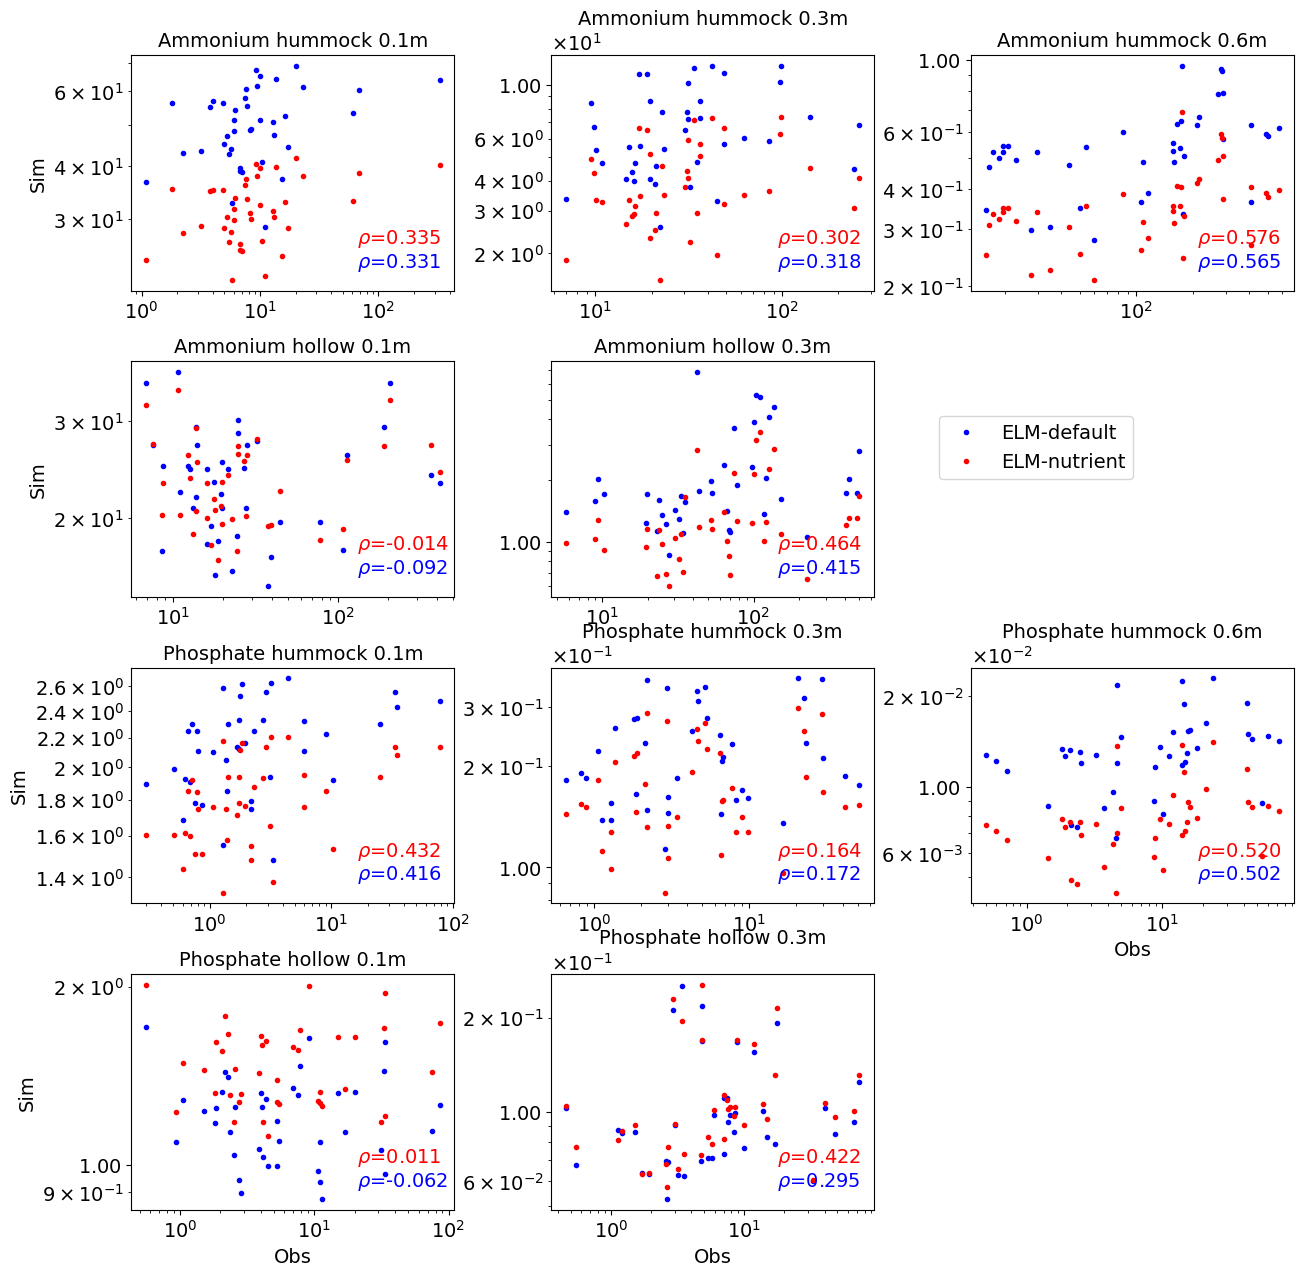

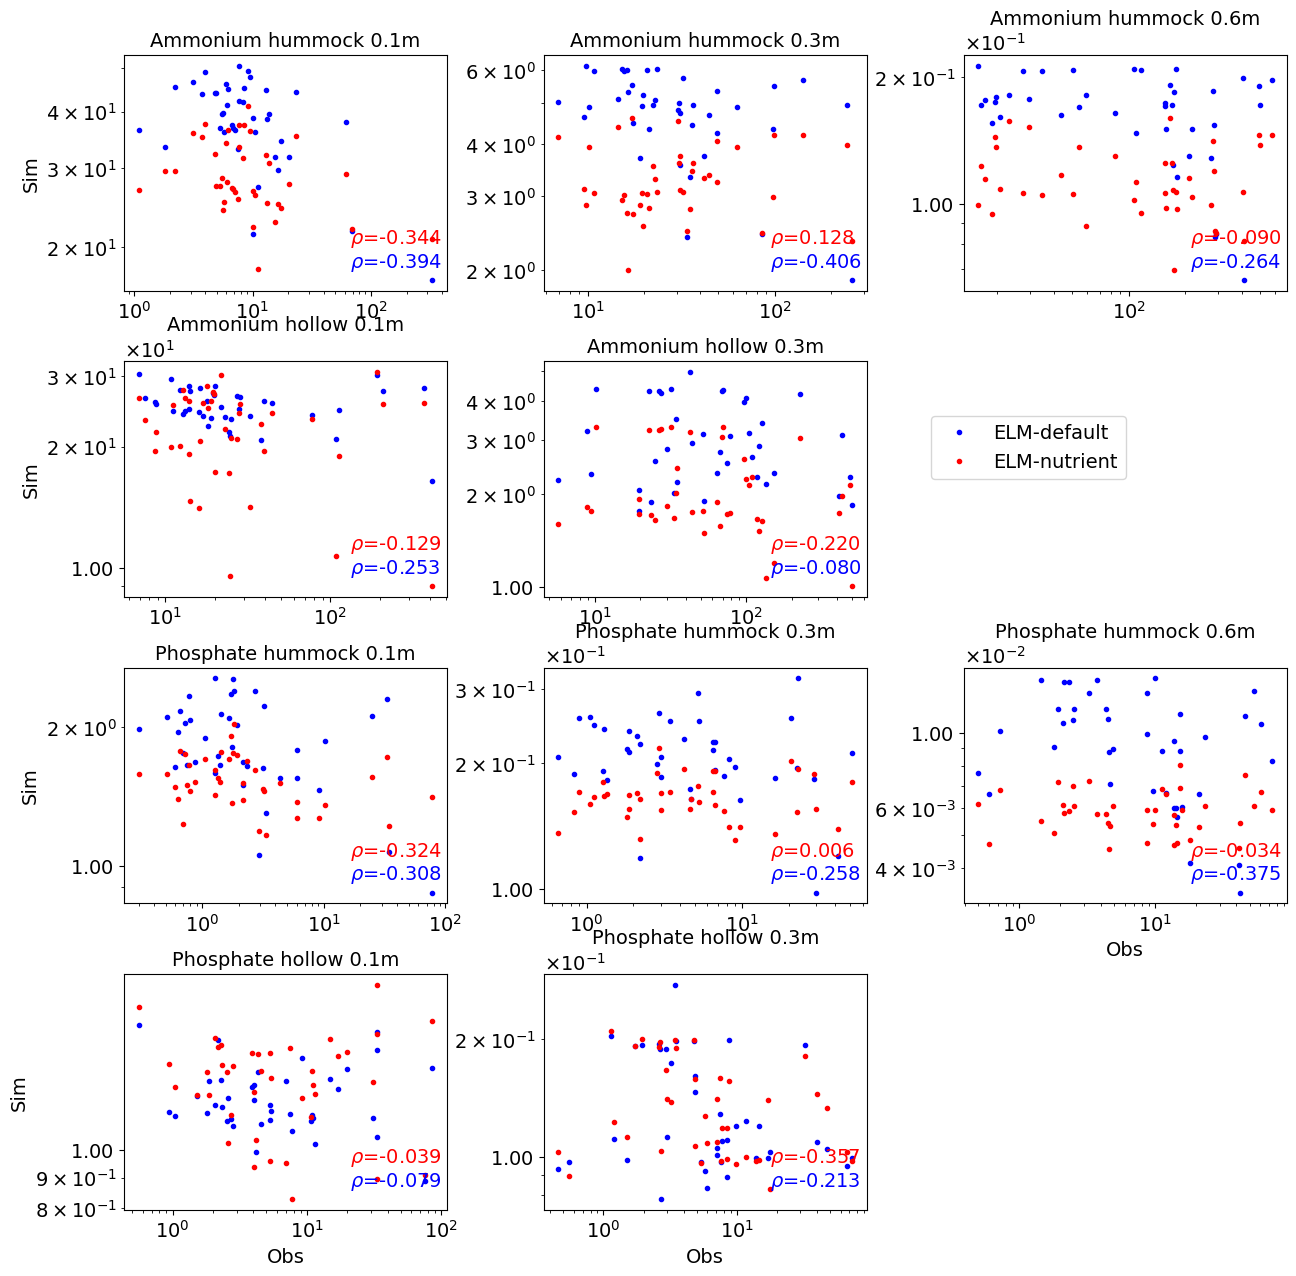

In [8]:
# clist = ['#1b9e77', '#d95f02', '#7570b3']

# Plot the correlation between observation and data
for sim_list in [['NET_NMIN', 'NET_PMIN'], ['SMINN_TO_PLANT', 'SMINP_TO_PLANT']]:

    fig, axes = plt.subplots(4, 3, figsize = (15, 15), sharex = False, sharey = False)
    fig.subplots_adjust(hspace = 0.3, wspace = 0.3)

    for n, nu, sim_name, obs_name in zip(
        [0, 1], ['N', 'P'], sim_list, ['Ammonium', 'Phosphate']
    ):
        for i, hol in enumerate(['hummock', 'hollow']):
            for d, depth in enumerate([0.1, 0.3, 0.6]):
                ax = axes.flat[n * 6 + i * 3 + d]

                if (hol == 'hollow') and (depth == 0.6):
                    ax.axis('off')
                    continue

                # observed temperature & data
                obs_temp = data.loc[(data['Microtopography'] == hol.capitalize()) &
                                    np.isclose(data['Peat_depth'], depth), 
                    ['Plot', 'Year', obs_name]].groupby(['Plot','Year']).mean()

                # growing season simulated data
                h = []
                for p, prefix, name, col in zip([0, 1], prefix_list, 
                                                ['ELM-default','ELM-nutrient'], ['b', 'r']):
                    sims_data_var = sims_data_annual[prefix][(sim_name, hol, depth)].unstack()
                    sims_data_var.index.names = ['Plot', 'Year']
                    sims_data_var = sims_data_var.to_frame(sim_name)

                    alldata = pd.concat([obs_temp, sims_data_var], axis = 1
                                        ).dropna(axis = 0, how = 'any')

                    ht, = ax.plot(alldata[obs_name], alldata[sim_name], 'o', color = col,
                                  markersize = 3)

                    rho, pval = spearmanr(alldata[obs_name], alldata[sim_name])
                    ax.text(0.7, 0.1+p/10, r'$\rho$=' + f'{rho:.3f}', transform = ax.transAxes, 
                            color = col)

                    h.append(ht)

                if (n == 0) & ((d == 1) & (i == 1)):
                    ax.legend(h, ['ELM-default', 'ELM-nutrient'], loc = [1.2, 0.5])

                if (n == 1) & ((d == 2) | (i == 1)):
                    ax.set_xlabel('Obs')
                if (d == 0):
                    ax.set_ylabel('Sim')
                ax.set_xscale('log')
                ax.set_yscale('log')
                ax.set_title(f'{obs_name} {hol} {depth}m')
                ax.yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    #if sim_list[0] == 'NET_NMIN':
    #    fig.suptitle('Net mineralization')
    #else:
    #    fig.suptitle('Plant uptake')